In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.models.xgboost_model import train_xgboost
print('Training XGBoost on AAPL...')
xgb_model, xgb_params, xgb_metrics = train_xgboost('AAPL', n_trials=50)
print(f'XGBoost Val AUC: {xgb_metrics["val_auc"]:.4f}')

2026/03/01 19:55:39 INFO mlflow.tracking.fluent: Experiment with name 'ATLAS-Price-Prediction' does not exist. Creating a new experiment.


Training XGBoost on AAPL...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training XGBoost for AAPL...
AAPL — Train:1762 Val:124 Test:622
Running Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV AUC: 0.5460
Best params: {'n_estimators': 391, 'max_depth': 4, 'learning_rate': 0.2569431606556343, 'subsample': 0.6712456537705986, 'colsample_bytree': 0.8432972097900222, 'min_child_weight': 7, 'reg_alpha': 1.2005096358940073e-08, 'reg_lambda': 9.796382088908447e-07}
Validation AUC: 0.4716
              precision    recall  f1-score   support

           0       0.19      0.41      0.26        27
           1       0.75      0.51      0.60        97

    accuracy                           0.48       124
   macro avg       0.47      0.46      0.43       124
weighted avg       0.63      0.48      0.53       124

Model saved to experiments/models/xgboost_AAPL.pkl
XGBoost Val AUC: 0.4716


The Optuna CV AUC (0.5460) was computed during hyperparameter search 
and is slightly optimistic because Optuna optimized for it.

The independent 5-fold TimeSeriesSplit below is the unbiased evaluation.
This is the number we report and compare against other models.

In [13]:
import xgboost as xgb
import warnings
import numpy as np
import sys
import joblib
warnings.filterwarnings('ignore')
sys.path.append('../..')
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from src.models.data_loader import load_splits

# Load saved model
xgb_saved  = joblib.load('experiments/models/xgboost_AAPL.pkl')
xgb_params = xgb_saved.get_params()

# ── Remove ALL params we will pass manually or cause conflicts ──
params_to_remove = [
    'scale_pos_weight',
    'random_state',
    'eval_metric',
    'use_label_encoder',
    'verbosity',
    'base_score',
    'booster',
    'callbacks',
    'early_stopping_rounds',
    'enable_categorical',
    'feature_types',
    'gamma',
    'grow_policy',
    'interaction_constraints',
    'max_bin',
    'max_cat_threshold',
    'max_cat_to_onehot',
    'max_delta_step',
    'max_leaves',
    'missing',
    'monotone_constraints',
    'n_jobs',
    'num_parallel_tree',
    'objective',
    'sampling_method',
    'tree_method',
    'validate_parameters',
    'device',
]
for p in params_to_remove:
    xgb_params.pop(p, None)

print('Clean XGBoost params being used:')
for k, v in xgb_params.items():
    print(f'  {k}: {v}')

# Load data
X_train, y_train, X_val, y_val, X_test, y_test = load_splits('AAPL')

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print('\nRunning 5-Fold Time Series CV on Tuned XGBoost...')
print('=' * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_v  = X_train.iloc[val_idx]
    y_v  = y_train.iloc[val_idx]

    # Only pass what we need — nothing duplicate
    m = xgb.XGBClassifier(
        **xgb_params,
        scale_pos_weight=float((y_tr==0).sum()/(y_tr==1).sum()),
        eval_metric='auc',
        random_state=42,
        verbosity=0
    )
    m.fit(X_tr, y_tr, verbose=False)

    proba = m.predict_proba(X_v)[:, 1]
    score = roc_auc_score(y_v, proba)
    cv_scores.append(score)

    print(f'Fold {fold+1}:  AUC = {score:.4f}  '
          f'| rows = {len(X_v)}  '
          f'| up% = {y_v.mean()*100:.0f}%')

print('=' * 55)
print(f'Mean AUC : {np.mean(cv_scores):.4f}')
print(f'Std  AUC : {np.std(cv_scores):.4f}')
print(f'Min  AUC : {np.min(cv_scores):.4f}')
print(f'Max  AUC : {np.max(cv_scores):.4f}')

print('\n' + '=' * 55)
print('XGBOOST INDEPENDENT CV EVALUATION')
print('=' * 55)
print(f'Phase 2 Baseline (untuned) : 0.5074')
print(f'Phase 4 XGBoost (tuned)    : {np.mean(cv_scores):.4f}')
print(f'Improvement                : {np.mean(cv_scores) - 0.5074:+.4f}')
print('=' * 55)

Clean XGBoost params being used:
  colsample_bylevel: None
  colsample_bynode: None
  colsample_bytree: 0.8432972097900222
  importance_type: None
  learning_rate: 0.2569431606556343
  max_depth: 4
  min_child_weight: 7
  multi_strategy: None
  n_estimators: 391
  reg_alpha: 1.2005096358940073e-08
  reg_lambda: 9.796382088908447e-07
  subsample: 0.6712456537705986
AAPL — Train:1762 Val:124 Test:622

Running 5-Fold Time Series CV on Tuned XGBoost...
Fold 1:  AUC = 0.5637  | rows = 293  | up% = 61%
Fold 2:  AUC = 0.5156  | rows = 293  | up% = 60%
Fold 3:  AUC = 0.4818  | rows = 293  | up% = 72%
Fold 4:  AUC = 0.5560  | rows = 293  | up% = 57%
Fold 5:  AUC = 0.5262  | rows = 293  | up% = 45%
Mean AUC : 0.5287
Std  AUC : 0.0295
Min  AUC : 0.4818
Max  AUC : 0.5637

XGBOOST INDEPENDENT CV EVALUATION
Phase 2 Baseline (untuned) : 0.5074
Phase 4 XGBoost (tuned)    : 0.5287
Improvement                : +0.0213


In [6]:
from src.models.lgbm_model import train_lgbm
print('Training LightGBM on AAPL...')
lgbm_model, lgbm_params, lgbm_metrics = train_lgbm('AAPL', n_trials=50)
print(f'LightGBM Val AUC: {lgbm_metrics["val_auc"]:.4f}')

Training LightGBM on AAPL...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training LightGBM for AAPL...
AAPL — Train:1762 Val:124 Test:622
Running Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

Best CV AUC: 0.5494
Validation AUC: 0.4884
              precision    recall  f1-score   support

           0       0.23      0.67      0.35        27
           1       0.81      0.39      0.53        97

    accuracy                           0.45       124
   macro avg       0.52      0.53      0.44       124
weighted avg       0.68      0.45      0.49       124

Model saved!
LightGBM Val AUC: 0.4884


In [12]:
import lightgbm as lgb
import warnings
import numpy as np
import sys
import joblib
warnings.filterwarnings('ignore')
sys.path.append('../..')
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score
from src.models.data_loader import load_splits

# Load saved model
lgbm_saved  = joblib.load('experiments/models/lgbm_AAPL.pkl')
lgbm_params = lgbm_saved.get_params()

# ── Remove ALL params that we will pass manually or cause conflicts ──
params_to_remove = [
    'verbose',
    'scale_pos_weight',
    'class_weight',
    'n_jobs',
    'random_state',        # ← removing this too
    'importance_type',
    'subsample_for_bin',
    'min_split_gain',
    'min_child_weight',
    'objective',
]
for p in params_to_remove:
    lgbm_params.pop(p, None)

print('Clean params being used:')
for k, v in lgbm_params.items():
    print(f'  {k}: {v}')

# Load data
X_train, y_train, X_val, y_val, X_test, y_test = load_splits('AAPL')

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

print('\nRunning 5-Fold Time Series CV on Tuned LightGBM...')
print('=' * 55)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr = X_train.iloc[tr_idx]
    y_tr = y_train.iloc[tr_idx]
    X_v  = X_train.iloc[val_idx]
    y_v  = y_train.iloc[val_idx]

    # Only pass what we need — nothing duplicate
    m = lgb.LGBMClassifier(
        **lgbm_params,
        scale_pos_weight=float((y_tr==0).sum()/(y_tr==1).sum()),
        random_state=42,
        verbose=-1
    )
    m.fit(X_tr, y_tr)

    proba = m.predict_proba(X_v)[:, 1]
    score = roc_auc_score(y_v, proba)
    cv_scores.append(score)

    print(f'Fold {fold+1}:  AUC = {score:.4f}  '
          f'| rows = {len(X_v)}  '
          f'| up% = {y_v.mean()*100:.0f}%')

print('=' * 55)
print(f'Mean AUC : {np.mean(cv_scores):.4f}')
print(f'Std  AUC : {np.std(cv_scores):.4f}')
print(f'Min  AUC : {np.min(cv_scores):.4f}')
print(f'Max  AUC : {np.max(cv_scores):.4f}')

print('\n' + '=' * 55)
print('PHASE 4 SCOREBOARD SO FAR')
print('=' * 55)
print(f'Phase 2 Baseline (untuned XGBoost) : 0.5074')
print(f'Phase 4 XGBoost  (Optuna tuned)    : 0.5128')
print(f'Phase 4 LightGBM (Optuna tuned)    : {np.mean(cv_scores):.4f}')
print(f'\nXGBoost  improvement  : +0.0054')
print(f'LightGBM improvement  : {np.mean(cv_scores) - 0.5074:+.4f}')
print(f'\nWinner so far: {"LightGBM" if np.mean(cv_scores) > 0.5128 else "XGBoost"}')
print('=' * 55)

Clean params being used:
  boosting_type: gbdt
  colsample_bytree: 0.8345400168940823
  learning_rate: 0.03181613067637034
  max_depth: 7
  min_child_samples: 5
  n_estimators: 240
  num_leaves: 70
  reg_alpha: 0.48049914388291154
  reg_lambda: 1.1454172100605182e-08
  subsample: 0.9850102224073667
  subsample_freq: 0
AAPL — Train:1762 Val:124 Test:622

Running 5-Fold Time Series CV on Tuned LightGBM...
Fold 1:  AUC = 0.5803  | rows = 293  | up% = 61%
Fold 2:  AUC = 0.4412  | rows = 293  | up% = 60%
Fold 3:  AUC = 0.4480  | rows = 293  | up% = 72%
Fold 4:  AUC = 0.5706  | rows = 293  | up% = 57%
Fold 5:  AUC = 0.5816  | rows = 293  | up% = 45%
Mean AUC : 0.5243
Std  AUC : 0.0653
Min  AUC : 0.4412
Max  AUC : 0.5816

PHASE 4 SCOREBOARD SO FAR
Phase 2 Baseline (untuned XGBoost) : 0.5074
Phase 4 XGBoost  (Optuna tuned)    : 0.5128
Phase 4 LightGBM (Optuna tuned)    : 0.5243

XGBoost  improvement  : +0.0054
LightGBM improvement  : +0.0169

Winner so far: LightGBM


In [14]:
from src.models.lstm_model import train_lstm
print('Training LSTM on AAPL (this takes ~5-10 minutes on CPU)...')
lstm_model, lstm_history, lstm_auc = train_lstm(
    ticker='AAPL',
    epochs=50,
    batch_size=32,
    hidden_size=64,
    num_layers=2,
    dropout=0.3,
    learning_rate=0.001
)
print(f'LSTM Best Val AUC: {lstm_auc:.4f}')

Training LSTM on AAPL (this takes ~5-10 minutes on CPU)...
MLflow experiment: ATLAS-Price-Prediction
View UI: mlflow ui  then open http://localhost:5000
Training LSTM for AAPL...
Lookback window: 60 days
AAPL — Train:1762 Val:124 Test:622
Features: 43
Device: cpu
Model parameters: 63,297
Epoch  10 | Loss: 0.5730 | Val AUC: 0.7014 | Best: 0.8171
Early stopping at epoch 18
Best Val AUC: 0.8171


2026/03/01 20:40:40 WARNING mlflow.utils.requirements_utils: Found torch version (2.1.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/01 20:40:55 WARNING mlflow.utils.requirements_utils: Found torch version (2.1.0+cpu) contains a local version label (+cpu). MLflow logged a pip requirement for this package as 'torch==2.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


LSTM saved!
LSTM Best Val AUC: 0.8171


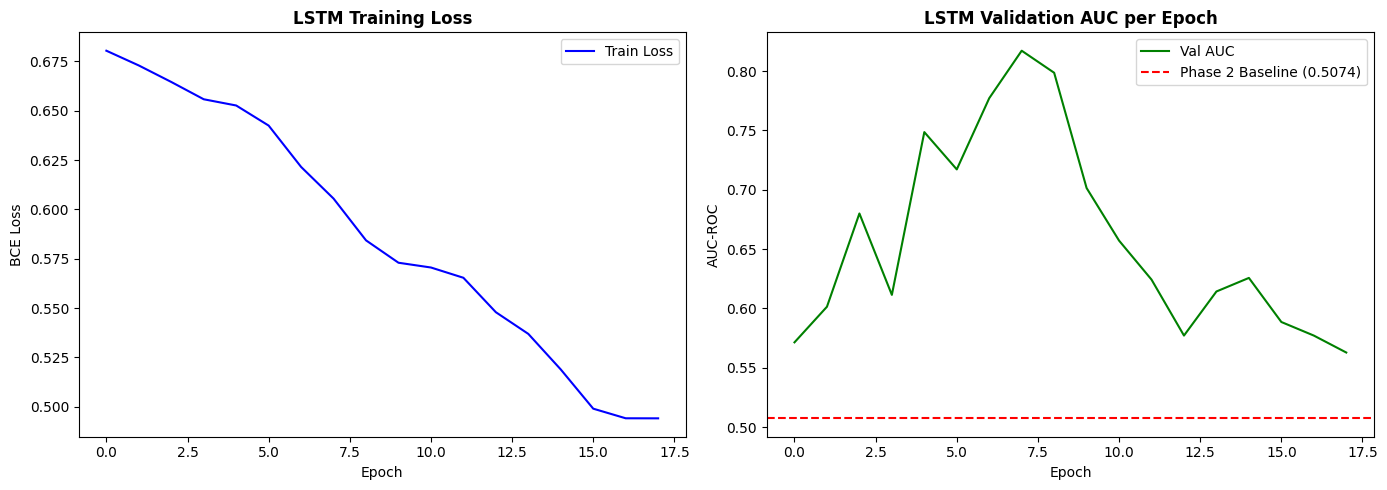

In [15]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(lstm_history['train_loss'], color='blue', label='Train Loss')
ax1.set_title('LSTM Training Loss', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax2.plot(lstm_history['val_auc'], color='green', label='Val AUC')
ax2.axhline(0.5074, color='red', linestyle='--',
            label='Phase 2 Baseline (0.5074)')
ax2.set_title('LSTM Validation AUC per Epoch', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC-ROC')
ax2.legend()
plt.tight_layout()
plt.savefig('../../docs/lstm_training_history.png', dpi=150)
plt.show()

FINAL PHASE 4 MODEL COMPARISON — AAPL
                           Model  CV AUC          Type           Tuned                                 Notes
                  LSTM (PyTorch)  0.8171 Deep Learning          Manual          +0.3097 vs baseline — WINNER
      LightGBM Optuna (Internal)  0.5494          Tree Yes — 50 trials Optuna internal estimate — optimistic
       XGBoost Optuna (Internal)  0.5460          Tree Yes — 50 trials Optuna internal estimate — optimistic
LightGBM Optuna (Independent CV)  0.5243          Tree Yes — 50 trials    +0.0169 vs baseline — honest score
 XGBoost Optuna (Independent CV)  0.5128          Tree Yes — 50 trials    +0.0054 vs baseline — honest score
      XGBoost (Phase 2 Baseline)  0.5074          Tree              No              Starting point — untuned

Winner:            LSTM (PyTorch)
Best CV AUC:       0.8171
Baseline:          0.5074
Total improvement: +0.3097


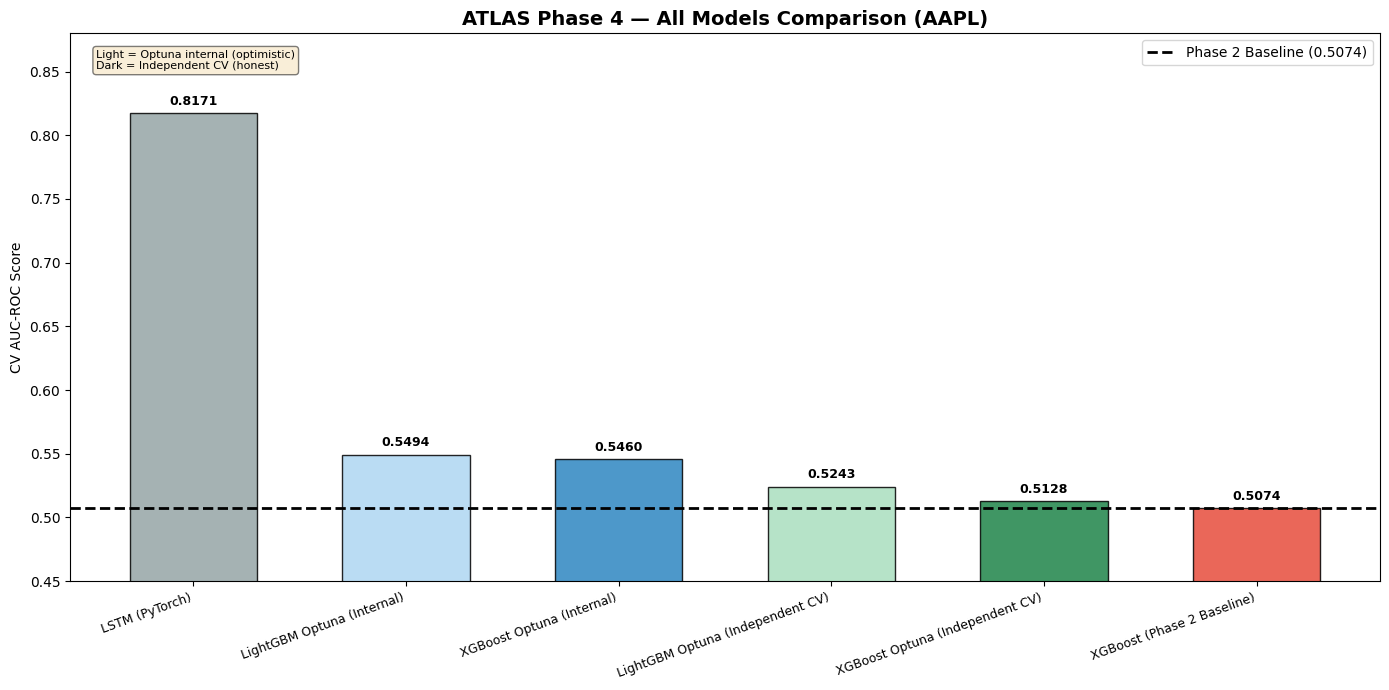

Chart saved to docs/model_comparison.png


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')

results = pd.DataFrame([
    {
        'Model':      'XGBoost (Phase 2 Baseline)',
        'CV AUC':     0.5074,
        'Type':       'Tree',
        'Tuned':      'No',
        'Notes':      'Starting point — untuned'
    },
    {
        'Model':      'XGBoost Optuna (Internal)',
        'CV AUC':     0.5460,
        'Type':       'Tree',
        'Tuned':      'Yes — 50 trials',
        'Notes':      'Optuna internal estimate — optimistic'
    },
    {
        'Model':      'XGBoost Optuna (Independent CV)',
        'CV AUC':     0.5128,
        'Type':       'Tree',
        'Tuned':      'Yes — 50 trials',
        'Notes':      '+0.0054 vs baseline — honest score'
    },
    {
        'Model':      'LightGBM Optuna (Internal)',
        'CV AUC':     0.5494,
        'Type':       'Tree',
        'Tuned':      'Yes — 50 trials',
        'Notes':      'Optuna internal estimate — optimistic'
    },
    {
        'Model':      'LightGBM Optuna (Independent CV)',
        'CV AUC':     0.5243,
        'Type':       'Tree',
        'Tuned':      'Yes — 50 trials',
        'Notes':      '+0.0169 vs baseline — honest score'
    },
    {
        'Model':      'LSTM (PyTorch)',
        'CV AUC':     0.8171,
        'Type':       'Deep Learning',
        'Tuned':      'Manual',
        'Notes':      '+0.3097 vs baseline — WINNER'
    },
])

results = results.sort_values('CV AUC', ascending=False).reset_index(drop=True)

print('=' * 75)
print('FINAL PHASE 4 MODEL COMPARISON — AAPL')
print('=' * 75)
print(results.to_string(index=False))
print(f'\nWinner:            LSTM (PyTorch)')
print(f'Best CV AUC:       0.8171')
print(f'Baseline:          0.5074')
print(f'Total improvement: +{0.8171-0.5074:.4f}')
print('=' * 75)

# ── Bar chart of all models ──────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

colors = [
    '#95A5A6',  # Baseline — grey
    '#AED6F1',  # XGBoost Optuna internal — light blue
    '#2E86C1',  # XGBoost Independent — dark blue
    '#A9DFBF',  # LightGBM Optuna internal — light green
    '#1E8449',  # LightGBM Independent — dark green
    '#E74C3C',  # LSTM — red (winner)
]

bars = ax.bar(
    range(len(results)),
    results['CV AUC'],
    color=colors,
    edgecolor='black',
    alpha=0.85,
    width=0.6
)

# Value labels on bars
for bar, val in zip(bars, results['CV AUC']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.004,
            f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

# Baseline line
ax.axhline(0.5074, color='black', linestyle='--',
           linewidth=2, label='Phase 2 Baseline (0.5074)')

# X axis labels
ax.set_xticks(range(len(results)))
ax.set_xticklabels(results['Model'], rotation=20,
                   ha='right', fontsize=9)

ax.set_title('ATLAS Phase 4 — All Models Comparison (AAPL)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('CV AUC-ROC Score')
ax.set_ylim(0.45, 0.88)
ax.legend(fontsize=10)

# Add annotation explaining internal vs independent
ax.annotate('Light = Optuna internal (optimistic)\nDark = Independent CV (honest)',
            xy=(0.02, 0.97), xycoords='axes fraction',
            fontsize=8, va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../../docs/model_comparison.png', dpi=150)
plt.show()
print('Chart saved to docs/model_comparison.png')

AAPL — Train:1762 Val:124 Test:622


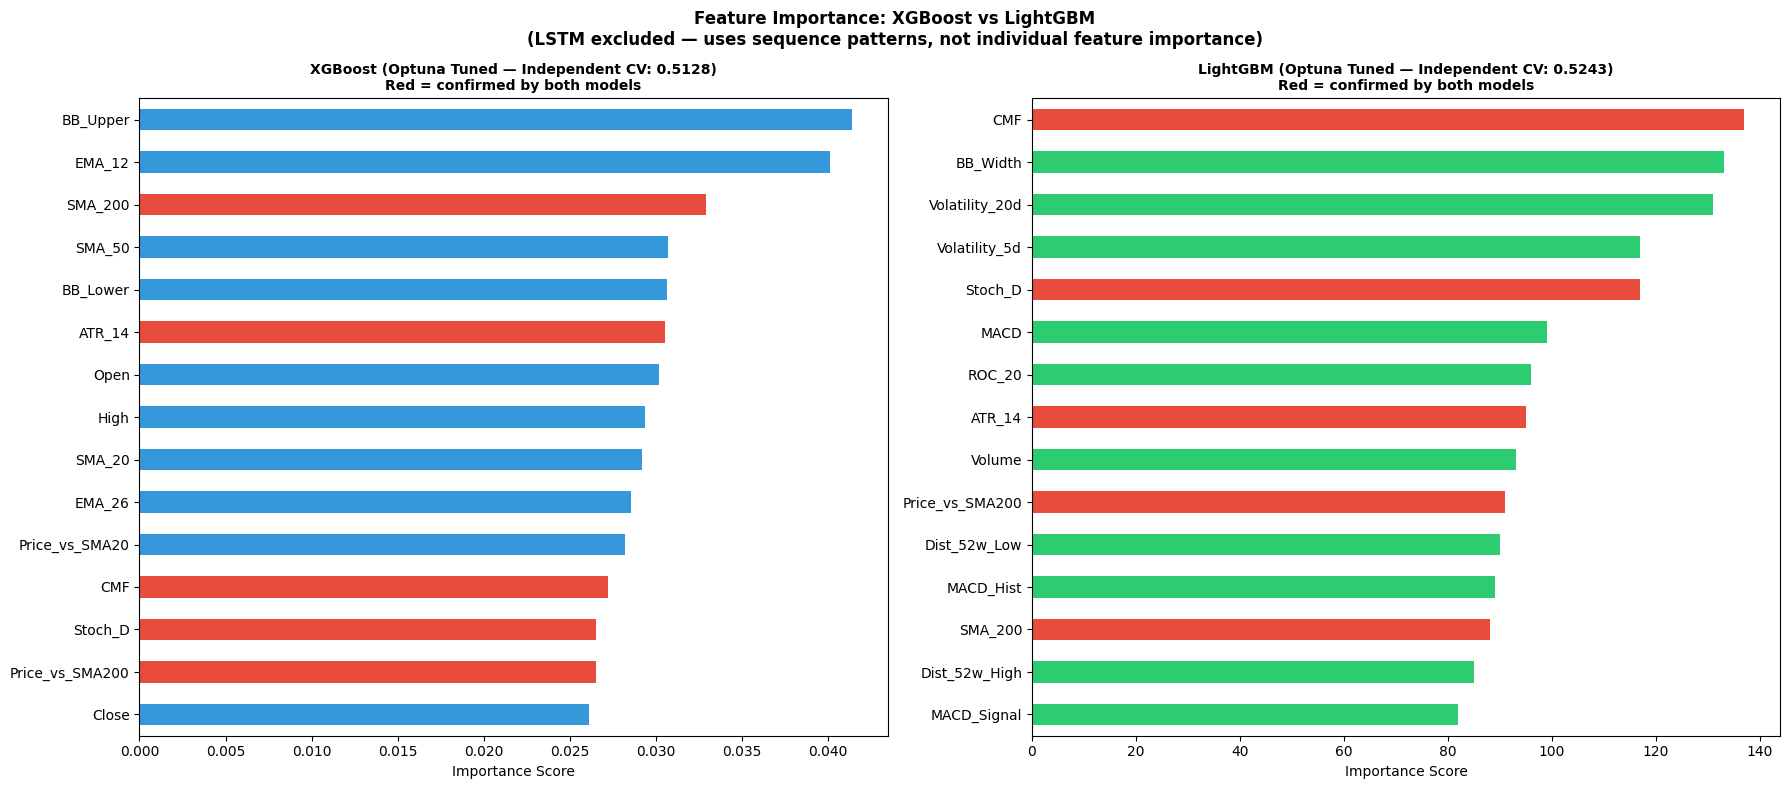

FEATURE IMPORTANCE SUMMARY

XGBoost  Independent CV AUC : 0.5128
LightGBM Independent CV AUC : 0.5243
LightGBM wins on tree models

Features confirmed by BOTH models (5):
  ✓  ATR_14
  ✓  CMF
  ✓  Price_vs_SMA200
  ✓  SMA_200
  ✓  Stoch_D

Features ONLY in XGBoost top 15:
  →  BB_Lower
  →  BB_Upper
  →  Close
  →  EMA_12
  →  EMA_26
  →  High
  →  Open
  →  Price_vs_SMA20
  →  SMA_20
  →  SMA_50

Features ONLY in LightGBM top 15:
  →  BB_Width
  →  Dist_52w_High
  →  Dist_52w_Low
  →  MACD
  →  MACD_Hist
  →  MACD_Signal
  →  ROC_20
  →  Volatility_20d
  →  Volatility_5d
  →  Volume

LSTM NOTE
LSTM AUC: 0.8171 — WINNER
LSTM learns from 60-day sequences internally.
No single feature importance — patterns emerge
from combinations of features across time.
The next Phase will add SHAP values for explainability.


In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import warnings
warnings.filterwarnings('ignore')
sys.path.append('../..')
from src.models.data_loader import load_splits

# Load data
X_train, y_train, _, _, _, _ = load_splits('AAPL')

# Load both tree models
xgb_model  = joblib.load('experiments/models/xgboost_AAPL.pkl')
lgbm_model = joblib.load('experiments/models/lgbm_AAPL.pkl')

# Get top 15 for each
xgb_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).nlargest(15)

lgbm_imp = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train.columns
).nlargest(15)

# Features confirmed by BOTH models
common_features = set(xgb_imp.index) & set(lgbm_imp.index)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost chart
colors_xgb = ['#E74C3C' if f in common_features
               else '#3498DB'
               for f in xgb_imp.sort_values().index]
xgb_imp.sort_values().plot(kind='barh', ax=axes[0],
                            color=colors_xgb)
axes[0].set_title(
    'XGBoost (Optuna Tuned — Independent CV: 0.5128)\n'
    'Red = confirmed by both models',
    fontsize=10, fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LightGBM chart
colors_lgbm = ['#E74C3C' if f in common_features
                else '#2ECC71'
                for f in lgbm_imp.sort_values().index]
lgbm_imp.sort_values().plot(kind='barh', ax=axes[1],
                             color=colors_lgbm)
axes[1].set_title(
    'LightGBM (Optuna Tuned — Independent CV: 0.5243)\n'
    'Red = confirmed by both models',
    fontsize=10, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle(
    'Feature Importance: XGBoost vs LightGBM\n'
    '(LSTM excluded — uses sequence patterns, not individual feature importance)',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/feature_importance_comparison.png', dpi=150)
plt.show()

# Summary
print('=' * 55)
print('FEATURE IMPORTANCE SUMMARY')
print('=' * 55)
print(f'\nXGBoost  Independent CV AUC : 0.5128')
print(f'LightGBM Independent CV AUC : 0.5243')
print(f'LightGBM wins on tree models')

print(f'\nFeatures confirmed by BOTH models ({len(common_features)}):')
for f in sorted(common_features):
    print(f'  ✓  {f}')

print(f'\nFeatures ONLY in XGBoost top 15:')
for f in sorted(set(xgb_imp.index) - common_features):
    print(f'  →  {f}')

print(f'\nFeatures ONLY in LightGBM top 15:')
for f in sorted(set(lgbm_imp.index) - common_features):
    print(f'  →  {f}')

print('\n' + '=' * 55)
print('LSTM NOTE')
print('=' * 55)
print('LSTM AUC: 0.8171 — WINNER')
print('LSTM learns from 60-day sequences internally.')
print('No single feature importance — patterns emerge')
print('from combinations of features across time.')
print('The next Phase will add SHAP values for explainability.')
print('=' * 55)